# Module 03: EDA

In [79]:
# packages
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
from sklearn.model_selection import train_test_split 
from ISLP import load_data

# set seed
seed = 2323

### We'll use the _Hitters_ data from ISLP for this activity. The metadata for _Hitters_ can be found [here](https://intro-stat-learning.github.io/ISLP/datasets/Hitters.html).

In [80]:
# Load the data
Hitters = load_data('Hitters')

### Determine the number of rows and columns in the dataset by returning its "shape" attribute

In [81]:
#fillin
Hitters.shape

(322, 20)

### Determine whether each feature is numeric or categorical by returning the "dtype" attribute for each column

In [82]:
for col in Hitters.columns:
    print(col, Hitters[col].dtype)

AtBat int64
Hits int64
HmRun int64
Runs int64
RBI int64
Walks int64
Years int64
CAtBat int64
CHits int64
CHmRun int64
CRuns int64
CRBI int64
CWalks int64
League category
Division category
PutOuts int64
Assists int64
Errors int64
Salary float64
NewLeague category


### Before doing any other analyses, let's create training and test sets.

In [83]:
Train, Test = train_test_split(Hitters, 
                               random_state=seed, 
                               test_size=0.40, 
                               shuffle=True) 

### Based on the metadata, what is the difference between the 6 columns starting with 'C' and the 6 related columns that don't?

The 6 columns starting with 'C' provide career data, while related columns without the 'C' provide data for only the 1986 season.

### On the training set, create pairwise scatterplots for each of these 6 columns with the 'Salary' variable.

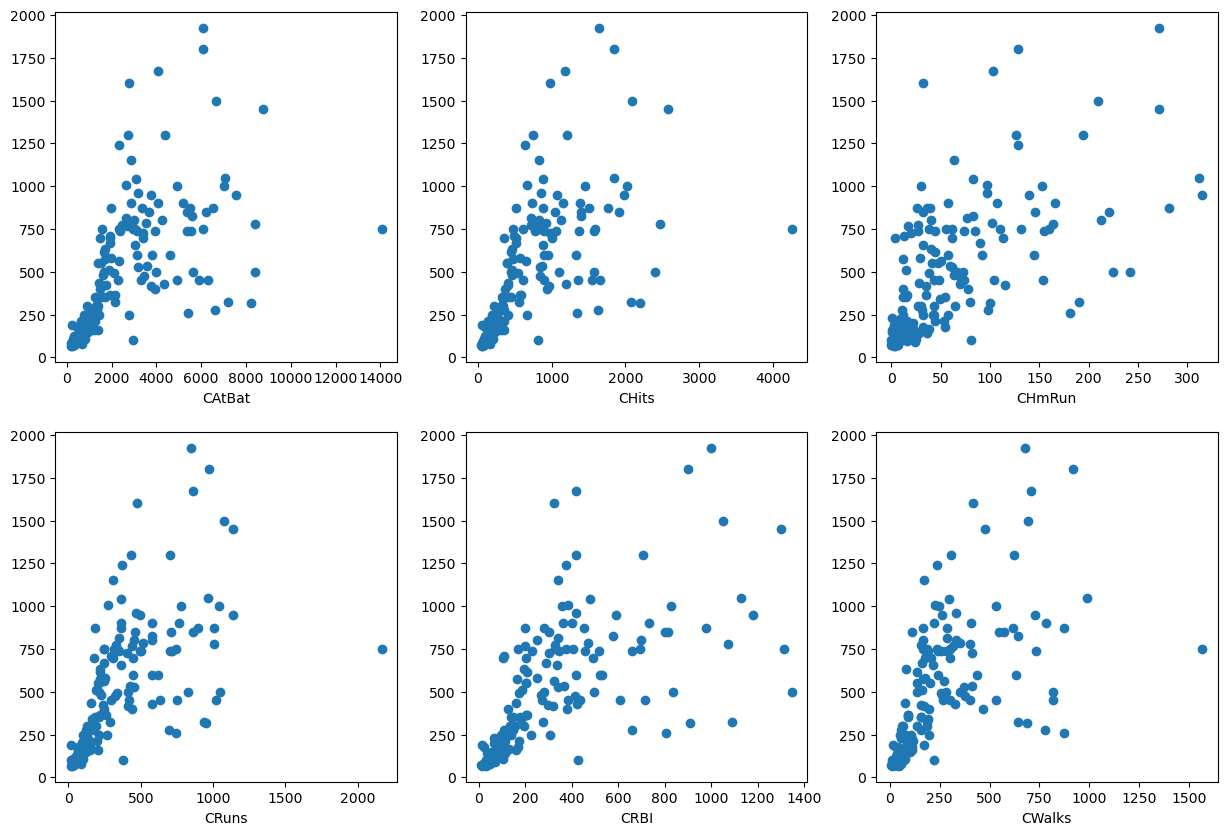

In [84]:
# First create a subset of the columns that we want to plot

subset = Train[['CAtBat', 'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks']]

# Initialize the plots before drawing them

fig, axes = subplots(nrows=2,
                     ncols=3,
                     figsize=(15, 10))
# Copy the helper function

def range_to_grid(i,Ncol):
    x=[]
    y=[]
    for n in range(Ncol**2):
        x.append(int(np.floor(n/Ncol)))
        y.append(n % Ncol)
        #print(n,x[n],y[n])
    return x[i],y[i]

# Plot the variables

for j in range(len(subset.columns)):
    axes[range_to_grid(j,3)[0],range_to_grid(j,3)[1]].plot(subset.iloc[:,j], Train['Salary'], 'o')
    axes[range_to_grid(j,3)[0],range_to_grid(j,3)[1]].set_xlabel(subset.columns[j])


### Use the "describe" method to determine the mean, standard deviation, and 5 number summary of all numeric variables in the training subset of _Hitters_.

In [88]:
#fillin

Train.describe()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary,AtBat_st
count,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,164.000000,1.930000e+02
mean,381.829016,101.549223,10.150259,50.751295,47.093264,38.445596,7.253886,2587.440415,702.222798,59.668394,345.378238,308.373057,248.388601,276.865285,105.300518,8.051813,493.032951,-2.761176e-17
std,145.679181,44.267521,8.228711,24.784284,24.912589,21.136915,4.858712,2285.947344,649.010165,66.449102,322.848870,297.885894,250.777436,262.957701,137.135778,6.783667,386.159522,1.000000e+00
min,19.000000,7.000000,0.000000,1.000000,2.000000,1.000000,1.000000,41.000000,13.000000,0.000000,3.000000,4.000000,4.000000,0.000000,0.000000,0.000000,67.500000,-2.490603e+00
25%,271.000000,68.000000,4.000000,32.000000,29.000000,22.000000,3.000000,730.000000,185.000000,14.000000,98.000000,82.000000,63.000000,109.000000,7.000000,3.000000,160.000000,-7.607746e-01
50%,369.000000,95.000000,8.000000,47.000000,43.000000,34.000000,6.000000,1876.000000,476.000000,36.000000,238.000000,202.000000,166.000000,211.000000,38.000000,6.000000,420.833500,-8.806348e-02
75%,508.000000,136.000000,14.000000,68.000000,61.000000,53.000000,11.000000,3754.000000,1000.000000,78.000000,494.000000,419.000000,332.000000,317.000000,173.000000,12.000000,750.000000,8.660880e-01
max,687.000000,223.000000,40.000000,130.000000,121.000000,105.000000,24.000000,14053.000000,4256.000000,315.000000,2165.000000,1348.000000,1566.000000,1320.000000,492.000000,32.000000,1925.571000,2.094815e+00


### It looks like the mean and median of 'AtBat' are nearly equal. This _might_ suggest that this variable is normally distributed. Create a histogram of 'AtBat' to check this hypothesis.

(array([ 1.,  0.,  3.,  4., 16., 19., 11., 19., 20., 11., 13., 13., 12.,
        16.,  9., 18.,  5.,  3.]),
 array([ 19.        ,  56.11111111,  93.22222222, 130.33333333,
        167.44444444, 204.55555556, 241.66666667, 278.77777778,
        315.88888889, 353.        , 390.11111111, 427.22222222,
        464.33333333, 501.44444444, 538.55555556, 575.66666667,
        612.77777778, 649.88888889, 687.        ]),
 <BarContainer object of 18 artists>)

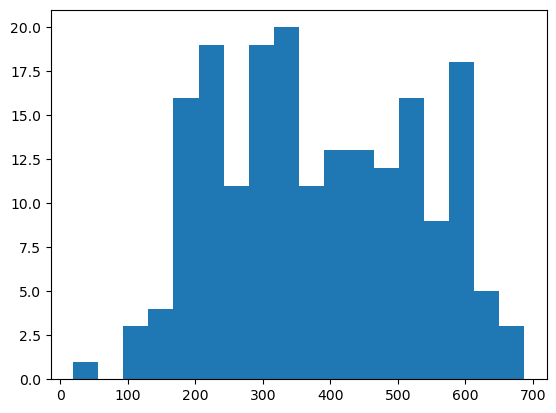

In [89]:
#fillin

plt.hist(Train['AtBat'], bins=18)

### Let's standardize the AtBat feature (i.e., normalize by z-scores). We'll create a new column in the training data called 'AtBat_st' to represent this.

In [90]:
Train['AtBat_st'] = (Train['AtBat'] - Train['AtBat'].mean()) / Train['AtBat'].std()

### How many rows have an 'AtBat' value within the first standard deviation?

Hint: the 'len' magic method returns the number of rows of a dataFrame.

In [91]:
#fillin

atbat_mean = Train['AtBat'].mean()
atbat_std = Train['AtBat'].std()

within_1_std = Train[(Train['AtBat'] >= (atbat_mean - atbat_std)) & (Train['AtBat'] <=(atbat_mean + atbat_std))]
print(len(within_1_std))

115


### Going back to the results of the 'describe' method, how can you tell that the 'Salary' variable has missing values?

It is clear that `Salary` variable has missing values because the sample size is 322, and all the columns have 322 values except for `Salary`, which has only 263 values, meaning that there are 59 missing values.

### Describe a situation where a variable could have missing values but this would not be reflected in the results of the 'describe' method.


The `describe()` method only treats missing values encoded as `NaN` or `None`, as `pd.read_csv` automatically converts common null strings like `"NULL"`, `"null"`, `"NA"`, `"N/A"`, `"NaN"`, and empty cells to `NaN`. However, there are other ways in which missing values are encoded, such as " ", "Unknown", "?", or even 0. Such missingness encodings are not picked up as missing values and would not be reflected in the `describe()` method.

### On the training data, create separate boxplots of the 'AtBat' variable for when 'Salary' is populated or missing.

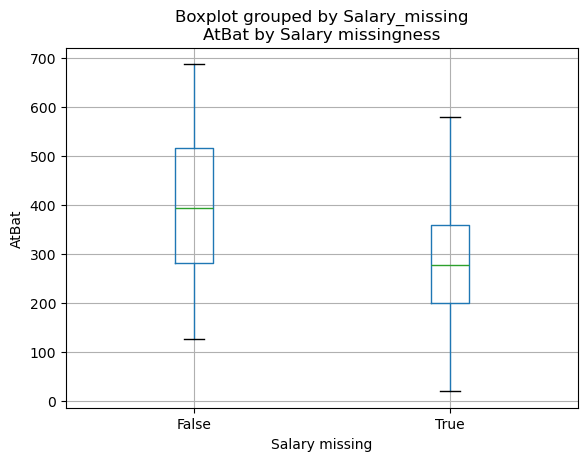

In [66]:
#fillin

Train["Salary_missing"] = Train["Salary"].isna()

Train.boxplot(column="AtBat", by="Salary_missing")
plt.title("AtBat by Salary missingness")
plt.xlabel("Salary missing")
plt.ylabel("AtBat")
plt.show()



### Create a correlation matrix for all numeric features in the training set

In [92]:
#fillin
corr_matrix = Train.corr(numeric_only=True)
print(corr_matrix)

             AtBat      Hits     HmRun      Runs       RBI     Walks  \
AtBat     1.000000  0.963324  0.540323  0.906579  0.798717  0.631824   
Hits      0.963324  1.000000  0.516853  0.914739  0.795316  0.605876   
HmRun     0.540323  0.516853  1.000000  0.618439  0.840613  0.385425   
Runs      0.906579  0.914739  0.618439  1.000000  0.786635  0.711346   
RBI       0.798717  0.795316  0.840613  0.786635  1.000000  0.553527   
Walks     0.631824  0.605876  0.385425  0.711346  0.553527  1.000000   
Years    -0.039232 -0.028717  0.009072 -0.069584  0.046705  0.037943   
CAtBat    0.126602  0.133316  0.078981  0.083770  0.165837  0.137157   
CHits     0.146763  0.163329  0.076914  0.103859  0.180526  0.147019   
CHmRun    0.150166  0.136865  0.411917  0.160979  0.375072  0.194766   
CRuns     0.164892  0.175542  0.110767  0.159683  0.191452  0.205250   
CRBI      0.145779  0.153011  0.218285  0.115628  0.285074  0.167453   
CWalks    0.056578  0.065178  0.080296  0.099025  0.117109  0.31

### Propose two different ways of imputing the missing values of Salary while taking advantage of the information given in the boxplots or the correlation matrix.

1. **Grouped-median approach:** the boxplots show that `AtBat` differs between players with and without a recorded salary, which means that missingness depends on `AtBat`. We can group the players by `AtBat` and fill each missing salary with the median salary of their group.

2. **Regression imputation (correlation matrix):** We can look at the variable that have the highest correlation with `Salary`. Based on the matrix, `Salary` correlates most strongly with the career statistics s(`CRBI`, `CRuns`, `CHits`). We can fit a regression of Salary on one or two of these variables using the complete rows, then use it to predict the missing salaries. This gives player-specific estimates rather than one value per group.

### For our last exercise, we'll explore Hits and Walks relative to AtBat totals. 
- Use the sum function to calculuate the totals of each of these three variables for the 1986 season (on the training set). 
- Create a pie chart which shows total hits, total walks, and remaining total (neither) as percents of the At Bats total (on the training set). 

In [93]:
TotHits = sum(Train['Hits'])
TotWalks = sum(Train['Walks'])
TotAtBat = sum(Train['AtBat'])

Labels = ['Hits', 'Walks', 'Neither']
Totals = [TotHits, TotWalks, TotAtBat-TotHits-TotWalks]

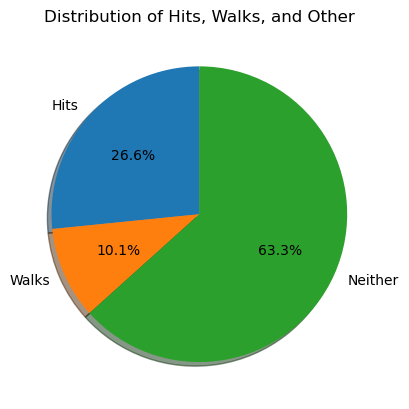

In [94]:
# pie chart

plt.pie(Totals, labels=Labels, autopct='%1.1f%%', shadow=True, startangle=90)
plt.title('Distribution of Hits, Walks, and Other')
plt.show()


### The previous two cells gave us totals across all players. For each player in the training set, calculate the Hits as a percent of AtBat and store it in a new variable called 'AVG'

In [95]:
Train['AVG'] = Train['Hits'] / Train['AtBat']


### Using 0.25 and 0.31 as the split points, create a new variable with three bins: high, medium, and low. 

In [96]:
Train['AVG_bin'] = 'medium'
Train['AVG_bin'][Train['AVG'] <= 0.25] = 'low'
Train['AVG_bin'][Train['AVG'] >= 0.31] = 'high'


/var/folders/5t/9lb8b6sx6r900y9rf7jzv1zr0000gn/T/ipykernel_26129/1662811566.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  Train['AVG_bin'][Train['AVG'] <= 0.25] = 'low'
/var/folders/5t/9lb8b6sx6r900y9rf7jzv1zr0000gn/T/ipykernel_26129/1

### Create a bar chart that displays the number of players in each of the low, medium, and high categories (for the training data).

In [97]:
Train['AVG_bin'].value_counts()

AVG_bin
medium    110
low        69
high       14
Name: count, dtype: int64

Notice that the order of the bars will be medium, low, high. That's counterintuitive. We can reorder these quickly. 

In [98]:
indexMap = ['low', 'medium', 'high']
reordered_list = [Train['AVG_bin'].value_counts()[i] for i in indexMap]

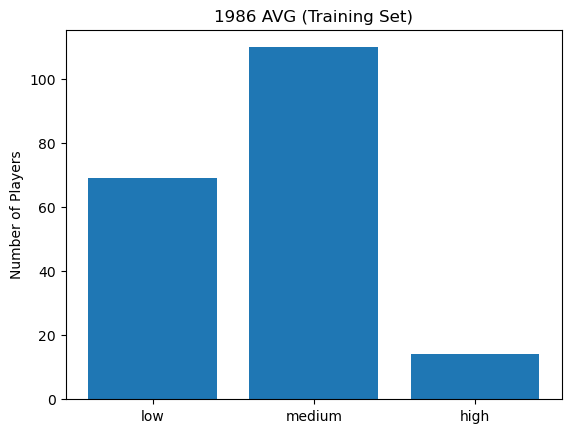

In [74]:
plt.bar([0, 1, 2], Train['AVG_bin'].value_counts()[['low', 'medium', 'high']])

plt.title("1986 AVG (Training Set)")
plt.ylabel("Number of Players")

plt.xticks([0, 1, 2], ['low', 'medium', 'high'])

plt.show()

### Did we use the depth method or width method for creating these bins? Explain.

Neither. The depth method chooses cut points so each bin contains the same number of players. The width method would divide the range of AVG into intervals of the same size. In this case, the medium bin spans only 0.06, while the low and high bins stretch from the split points out to the minimum and maximum AVG, which are much wider ranges.